In [55]:
import numpy as np
import vector as vec
import pandas as pd
from upkit import Histo
import matplotlib.pyplot as plt



In [56]:
def get_df_from_lund(file_path):
    """
    Reads a Lund file and returns a pandas DataFrame with the relevant information.
    Returns a dataframe with the following columns:
    - 'particle_id': The ID of the particle.
    - 'px': The x-component of the particle's momentum.
    - 'py': The y-component of the particle's momentum.
    - 'pz': The z-component of the particle's momentum.

    
    Parameters:
    file_path (str): The path to the Lund file.

    Returns:
    pd.DataFrame: A DataFrame containing the particle information.
    """

    rows = []

    with open(file_path, 'r') as file:
        for line in file:
            s = line.strip()
            if not s or s.startswith('#'):
                continue  # Skip empty lines and comments
            parts = s.split()
            if len(parts) < 13:
                continue  # Skip lines that don't have enough data
            particle_id = int(parts[3])
            px = float(parts[6])
            py = float(parts[7])
            pz = float(parts[8])
            rows.append({'particle_id': particle_id, 'px': px, 'py': py, 'pz': pz})
    return pd.DataFrame(rows)

In [57]:
df = get_df_from_lund('events.lund')

df_new = get_df_from_lund('events_nw.lund')

In [58]:
def get_4momentum(df):
    """
    Converts the momentum components in the DataFrame to 4-momentum vectors.
    
    Parameters:
    df (pd.DataFrame): A DataFrame containing the particle information with 'px', 'py', and 'pz' columns.

    Returns:
    vec.array: 4-momentum vector corresponding to the particle in the DataFrame.
    vec.array: 4-momentum vector corresponding to the particle in the DataFrame.
    vec.array: 4-momentum vector corresponding to the particle in the DataFrame.
    vec.array: 4-momentum vector corresponding to the particle in the DataFrame.
    """
    def compute_energy(row, mass):
        px = row['px']
        py = row['py']
        pz = row['pz']
        energy = np.sqrt(px**2 + py**2 + pz**2 + mass**2)
        return energy
    
    p_p1 = vec.array({
        'px': df.loc[0::4, 'px'],
        'py': df.loc[0::4, 'py'],
        'pz': df.loc[0::4, 'pz'],
        'E': compute_energy(df.loc[0::4], mass=0.938)  # Proton mass in GeV/c^2
    })

    p_p2 = vec.array({
        'px': df.loc[1::4, 'px'],
        'py': df.loc[1::4, 'py'],
        'pz': df.loc[1::4, 'pz'],
        'E': compute_energy(df.loc[1::4], mass=0.938)  # Proton mass in GeV/c^2
    })  

    p_e = vec.array({
        'px': df.loc[3::4, 'px'],
        'py': df.loc[3::4, 'py'],
        'pz': df.loc[3::4, 'pz'],
        'E': compute_energy(df.loc[3::4], mass=0.000511)  # Electron mass in GeV/c^2
    })

    p_pbar = vec.array({
        'px': df.loc[2::4, 'px'],
        'py': df.loc[2::4, 'py'],
        'pz': df.loc[2::4, 'pz'],
        'E': compute_energy(df.loc[2::4], mass=0.938)  # Antiproton mass in GeV/c^2
    })

    return p_p1, p_p2, p_e, p_pbar

In [59]:
p_p1, p_p2, p_e, p_pbar = get_4momentum(df)
p_p1_new, p_p2_new, p_e_new, p_pbar_new = get_4momentum(df_new)

In [60]:
p_p1p2 = p_p1 + p_p2
p_p1pbar = p_p1 + p_pbar
p_p2pbar = p_p2 + p_pbar

p_p1p2_new = p_p1_new + p_p2_new
p_p1pbar_new = p_p1_new + p_pbar_new
p_p2pbar_new = p_p2_new + p_pbar_new

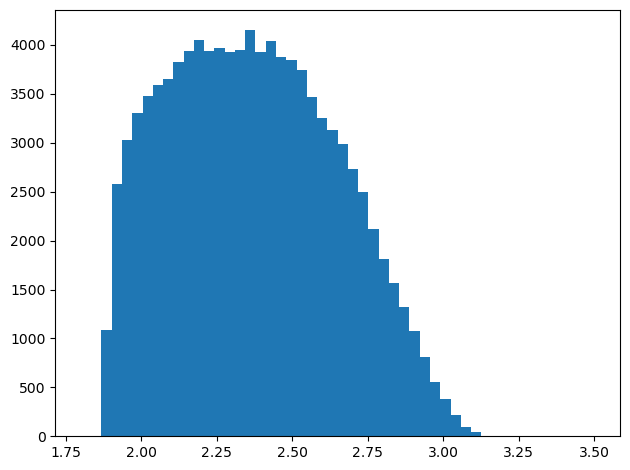

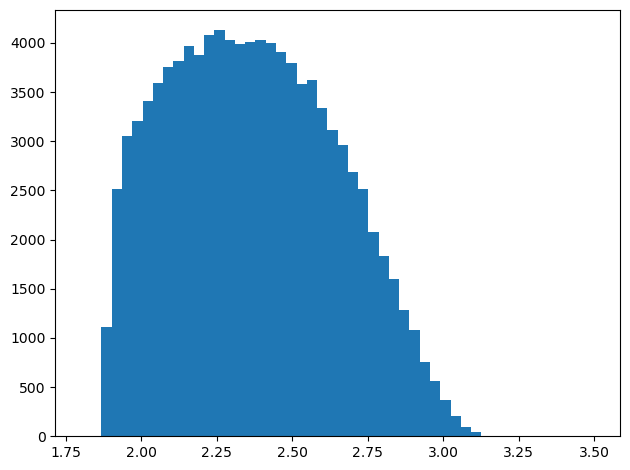

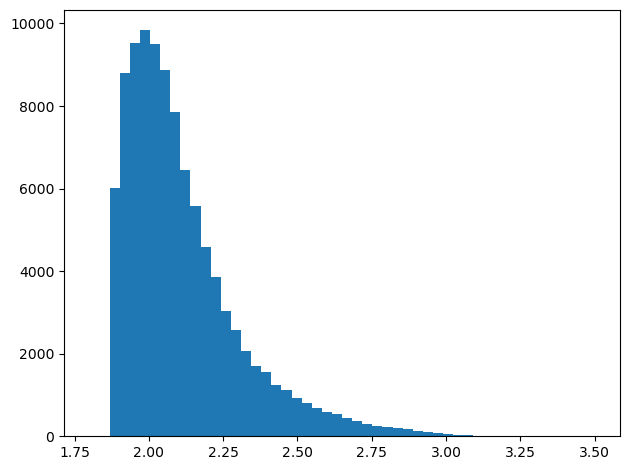

In [61]:
h_p1p2 = Histo(p_p1p2.mass, bins=50, range =(1.8, 3.5))
h_p1pbar = Histo(p_p1pbar.mass, bins=50, range =(1.8, 3.5))
h_p2pbar = Histo(p_p2pbar.mass, bins=50, range =(1.8, 3.5))

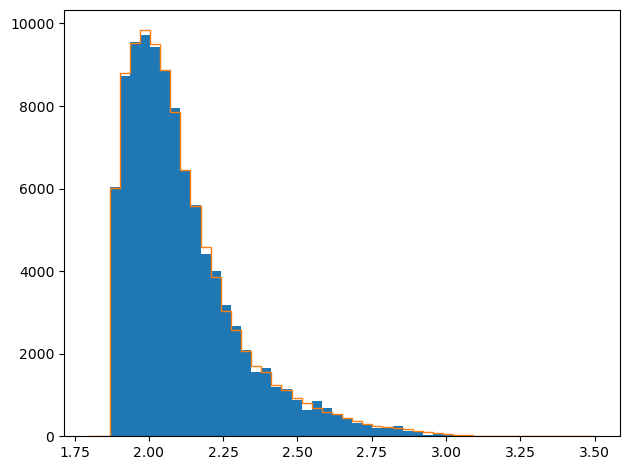

In [62]:
h_sum = h_p1pbar + h_p2pbar
plt.close()
h_sum.plot(bins=50, range=(1.8, 3.5))
plt.close()

h_tot = h_sum - h_p1p2
plt.close()
fig, ax = plt.subplots()
h_tot.plot(bins=50, range=(1.8, 3.5), ax=ax)
h_p2pbar.plot(bins=50, range=(1.8, 3.5), histtype='step',ax=ax)

In [63]:
p_beam = vec.obj(px=0, py=0, pz=10.2, E=10.2)
p_target = vec.obj(px=0, py=0, pz=0, E=0.938)

p_q = p_beam - p_e
p_w = p_q + p_target

p_q_new = p_beam - p_e_new
p_w_new = p_q_new + p_target

Text(0.5, 1.0, 'Electron Energy Distribution')

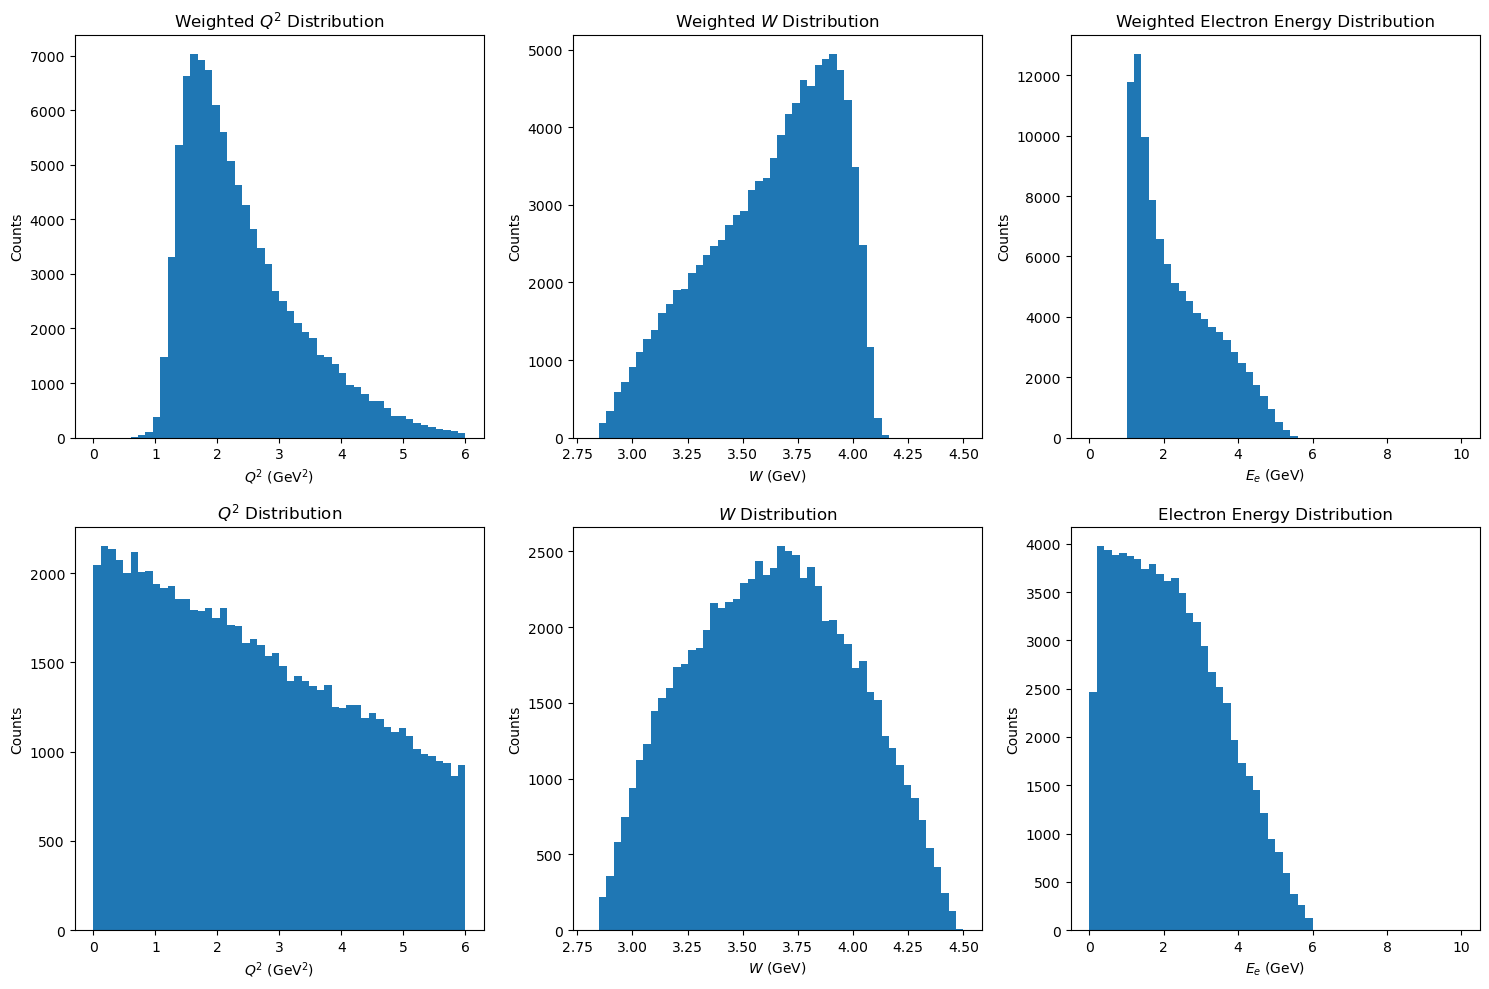

In [64]:
Q2 = -p_q.mass2
W = p_w.mass

Q2_new = -p_q_new.mass2
W_new = p_w_new.mass


fig, ax = plt.subplots(2, 3, figsize=(15, 10))
h_Q2 = Histo(Q2, bins=50, range=(0, 6), ax=ax[0, 0])
ax[0, 0].set_xlabel('$Q^2$ (GeV$^2$)')
ax[0, 0].set_ylabel('Counts')
ax[0, 0].set_title('Weighted $Q^2$ Distribution')

h_W = Histo(W, bins=50, range=(3*0.938, 4.5), ax=ax[0, 1])
ax[0, 1].set_xlabel('$W$ (GeV)')
ax[0, 1].set_ylabel('Counts')
ax[0, 1].set_title('Weighted $W$ Distribution')

h_p_e = Histo(p_e.E, bins=50, range=(0, 10), ax=ax[0, 2])
ax[0, 2].set_xlabel('$E_e$ (GeV)')
ax[0, 2].set_ylabel('Counts')
ax[0, 2].set_title('Weighted Electron Energy Distribution')

h_Q2_new = Histo(Q2_new, bins=50, range=(0, 6), ax=ax[1, 0])
ax[1, 0].set_xlabel('$Q^2$ (GeV$^2$)')
ax[1, 0].set_ylabel('Counts')
ax[1, 0].set_title('$Q^2$ Distribution')
h_W_new = Histo(W_new, bins=50, range=(3*0.938, 4.5), ax=ax[1, 1])
ax[1, 1].set_xlabel('$W$ (GeV)')
ax[1, 1].set_ylabel('Counts')
ax[1, 1].set_title('$W$ Distribution')
h_p_e_new = Histo(p_e_new.E, bins=50, range=(0, 10), ax=ax[1, 2])
ax[1, 2].set_xlabel('$E_e$ (GeV)')
ax[1, 2].set_ylabel('Counts')
ax[1, 2].set_title('Electron Energy Distribution')

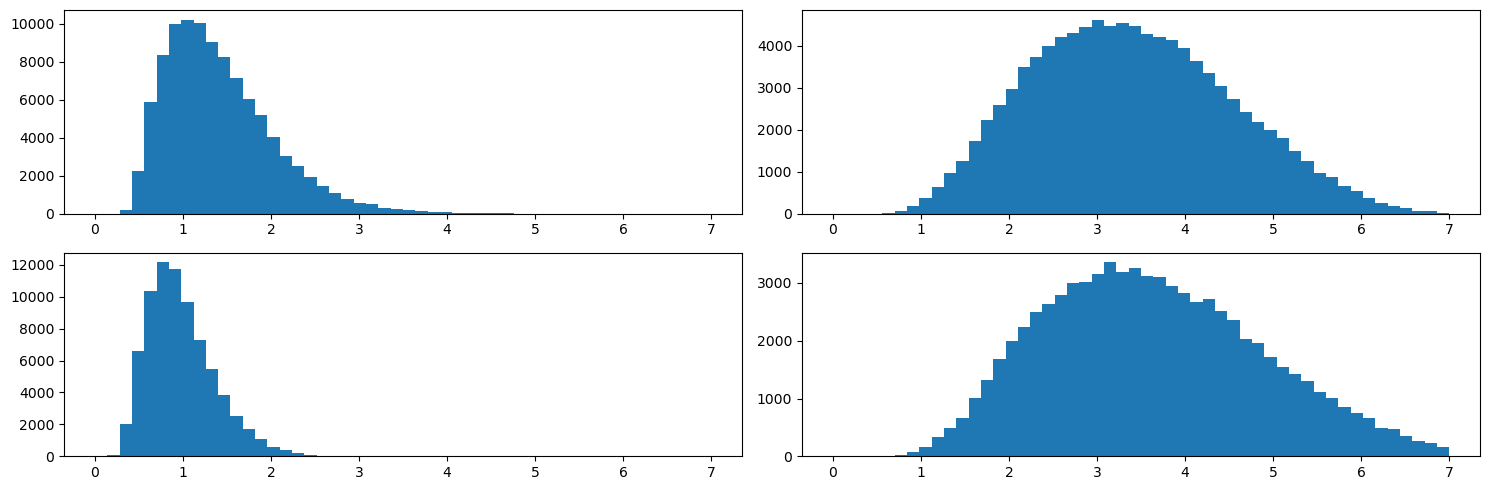

In [65]:

fig, ax = plt.subplots(2, 2, figsize=(15, 5))
Histo(p_p1.mag, bins=50, range=(0, 7), ax=ax[0, 0])
Histo(p_p2.mag, bins=50, range=(0, 7), ax=ax[0, 1])

Histo(p_p1_new.mag, bins=50, range=(0, 7), ax=ax[1, 0])
Histo(p_p2_new.mag, bins=50, range=(0, 7), ax=ax[1, 1])

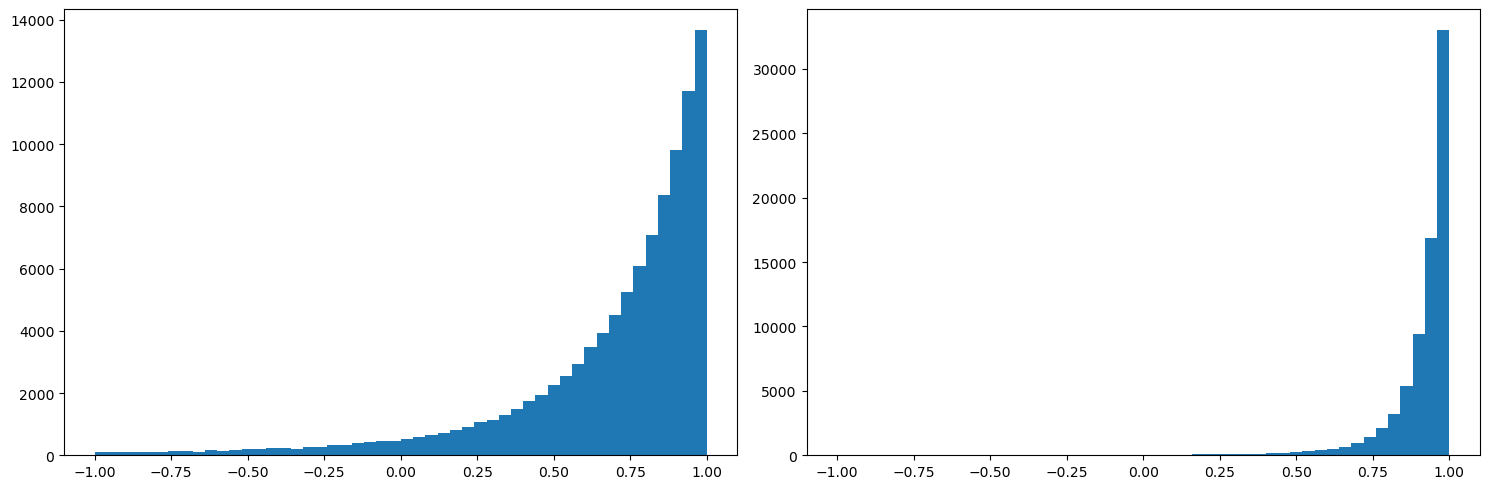

In [66]:
p2pbar_CM = p_p2pbar.boostCM_of(p_q + p_target)
p2pbar_CM_new = p_p2pbar_new.boostCM_of(p_q_new + p_target)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
Histo(p2pbar_CM.costheta, bins=50, range=(-1, 1), ax=ax[0])
Histo(p2pbar_CM_new.costheta, bins=50, range=(-1, 1), ax=ax[1])